In [1]:
# ambiente anaconda
import sys
print(sys.executable)

/home/fabiene/anaconda3/envs/YouTube/bin/python


## Dígitos ou caracteres escritos a mão

# Projeto 11: Rede Neural Convolucional MNIST

In [5]:
import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
# coleta dos dados online
from torchvision import datasets
# transformação e carregamentos da imagem
import torchvision.transforms as transforms
torch.__version__

'2.8.0+cu128'

In [4]:
import sys
print(sys.version)

3.12.8 | packaged by Anaconda, Inc. | (main, Dec 11 2024, 16:31:09) [GCC 11.2.0]


## Etapa 2: Base de dados

In [6]:
## semente para ter sempre o mesmo resultado
torch.manual_seed(123)

In [7]:
# download da imagem e vai converter para tensor
transform = transforms.ToTensor()

In [8]:
# dados 100% preparado para o pytorch, sem precisar converter para numpy a imagem e depois para o tensor, vai direto

In [10]:
# normalização, deixar em uma escala de 0 e 1.
# rede neural mais rápida
# divisão por 255

base de dados 100% preparada com os dados das figuras como Tensor (ToTensor())

e também com os dados normalizados 

In [13]:
#root salvar na imagem => .; criando para o train = True
#root salvar na imagem => .; criando para o train = False, para a base de teste

In [14]:
train = datasets.MNIST(root = '.', train = True, download=True, transform=transform)
test = datasets.MNIST(root = '.', train = False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:05<00:00, 1.67MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 143kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 681kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.50MB/s]


In [15]:
# download das imagens

In [19]:
train.data[0]
# primeiro registros das imagens, pixels, 0 é o preto, colorido é os outros números
# normalização das imagens de 0 a 255

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

In [17]:
train.data # matrizes

tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0,

### Instância do louder, normalização da imagem

In [20]:
train.data.shape

torch.Size([60000, 28, 28])

In [21]:

print(f'quantidade de imagens {train.data.shape[0]}, {train.data.shape[1]} por {train.data.shape[2]}')

print(f'{train.data.shape[1]} pixels de largura e {train.data.shape[2]} de altura.')



quantidade de imagens 60000, 28 por 28
28 pixels de largura e 28 de altura.


In [24]:
print(f'Cada uma das imagens possuem um total de {28*28} pixels.')

Cada uma das imagens possuem um total de 784 pixels.


#### 784 pixels para a camada de entrada da rede neural.

Como trabalhamos com redes neurais convolucionais, haverá uma série de processamentos nesses 784 pixels. Processos de camadas, para reduzir a dimensionalidade.

In [25]:
# cada imagem ou matriz representa um número
train.targets

tensor([5, 0, 4,  ..., 5, 6, 8])

In [27]:
len(train.targets) # quantidade de imagens

60000

In [28]:
# treinamento de 128 a 128 registros => batch_size
train_loader = torch.utils.data.DataLoader(train, batch_size=128)


In [29]:
test_loader = torch.utils.data.DataLoader(test, batch_size=128)

### visualizar a imagem 

In [31]:
# iter interação na base de dados train_loader
# view mudar as dimensões das imagens

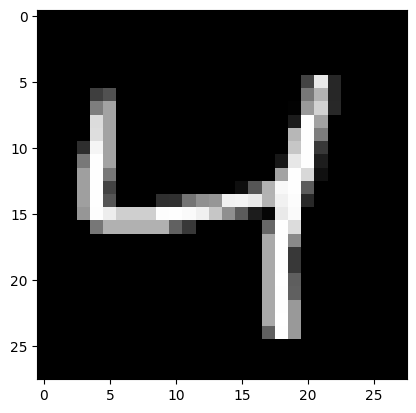

In [32]:
imagem = next(iter(train_loader))[0][2].view(28, 28) # (1, 1, 28, 28)
# imagem na escala cinza
plt.imshow(imagem, cmap='gray')

cmap =>

'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Grays', 'Grays_r', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'berlin', 'berlin_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r', 'cool', 'cool_r', 'coolwarm', 'coolwarm_r', 'copper', 'copper_r', 'cubehelix', 'cubehelix_r', 'flag', 'flag_r', 'gist_earth', 'gist_earth_r', 'gist_gray', 'gist_gray_r', 'gist_grey', 'gist_grey_r', 'gist_heat', 'gist_heat_r', 'gist_ncar', 'gist_ncar_r', 'gist_rainbow', 'gist_rainbow_r', 'gist_stern', 'gist_stern_r', 'gist_yarg', 'gist_yarg_r', 'gist_yerg', 'gist_yerg_r', 'gnuplot', 'gnuplot2', 'gnuplot2_r', 'gnuplot_r', 'gray', 'gray_r', 'grey', 'grey_r', 'hot', 'hot_r', 'hsv', 'hsv_r', 'inferno', 'inferno_r', 'jet', 'jet_r', 'magma', 'magma_r', 'managua', 'managua_r', 'nipy_spectral', 'nipy_spectral_r', 'ocean', 'ocean_r', 'pink', 'pink_r', 'plasma', 'plasma_r', 'prism', 'prism_r', 'rainbow', 'rainbow_r', 'seismic', 'seismic_r', 'spring', 'spring_r', 'summer', 'summer_r', 'tab10', 'tab10_r', 'tab20', 'tab20_r', 'tab20b', 'tab20b_r', 'tab20c', 'tab20c_r', 'terrain', 'terrain_r', 'turbo', 'turbo_r', 'twilight', 'twilight_r', 'twilight_shifted', 'twilight_shifted_r', 'vanimo', 'vanimo_r', 'viridis', 'viridis_r', 'winter', 'winter_r'

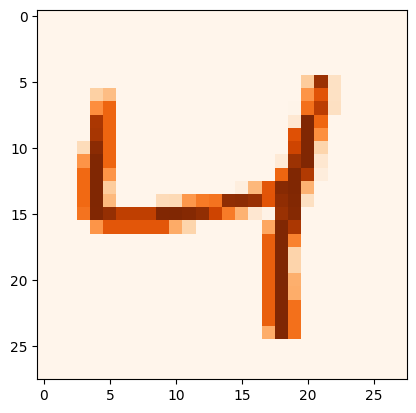

In [36]:
imagem = next(iter(train_loader))[0][2].view(28, 28) # (1, 1, 28, 28)

plt.imshow(imagem, cmap='Oranges')

loader, faz a divisão de batch_size, no exemplo de 128 para 128 imagens

retorna o batches, dados do treinamento em pixels e target (respostas reais que indicam qual número a imagem pertence). 

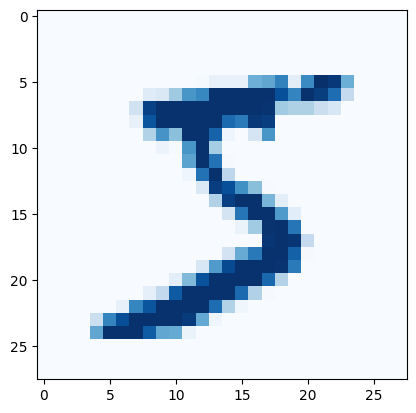

In [39]:
imagem = next(iter(train_loader))[0][0].view(28, 28) # (1, 1, 28, 28)
# imagem na escala azul
plt.imshow(imagem, cmap='Blues')

0 primeiro atributo previsores, e o segundo a a imagem [0][0].view()

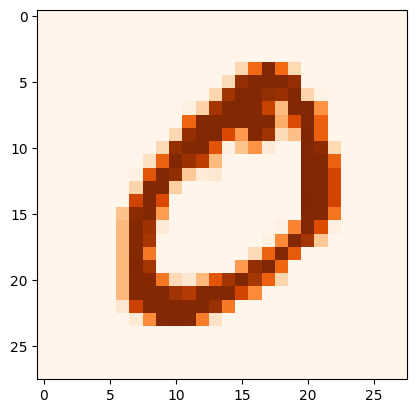

In [43]:
imagem = next(iter(train_loader))[0][1].view(28, 28) # (1, 1, 28, 28)
# (1 imagem, 1 filtro ou imagem (cinza é 1 canal de cor), 28 pixels altura, 28 pixels largura)
# imagem na escala laranja
plt.imshow(imagem, cmap='Oranges')

In [42]:
imagem.shape # 28 pixels de altura e 28 pixels de largura

torch.Size([28, 28])

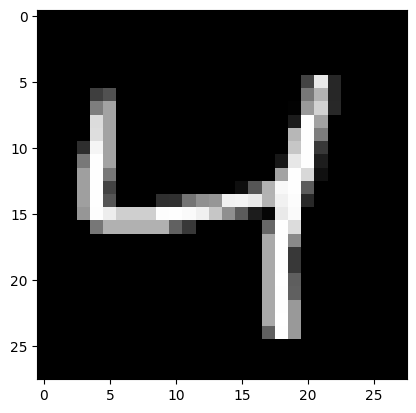

In [47]:
imagem = next(iter(train_loader))[0][2].view(28, 28) # (1, 1, 28, 28)
# (1 imagem, 1 filtro ou imagem (cinza é 1 canal de cor), 28 pixels altura, 28 pixels largura)
# imagem na escala cinza
plt.imshow(imagem, cmap='gray')

(array([669.,  10.,   7.,   9.,   8.,   5.,  27.,   5.,   8.,  36.]),
 array([0.        , 0.1       , 0.2       , 0.30000001, 0.40000001,
        0.5       , 0.60000002, 0.69999999, 0.80000001, 0.89999998,
        1.        ]),
 <BarContainer object of 10 artists>)

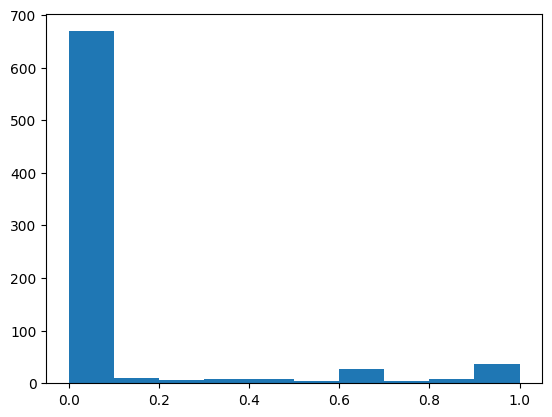

In [48]:
# view menos 1 (-1) para tirar a última dimensão do histograma
plt.hist(imagem.view(-1))

entre 0 e 1, do eixo x, submete os dados do train_loader, e vai fazer a normalização da imagem. 